[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 투빅스 25&26기 2주차 2교시 — Deep Learning 과제 [sklearn `digits` 손글씨 분류]


## 과제 목적

이번 과제는 `sklearn`의 `digits` 데이터셋을 이용해 **MLP를 직접 학습**하고, DNN의 세 가지 고질병인 **Vanishing Gradient · Overfitting · Optimization**을 실제 실험 결과로 확인하는 프로젝트입니다. §1.1에서는 데이터를 확인하고 train / validation / test로 분리하며, §1.2에서는 PyTorch로 미니배치 SGD 학습 루프를 완성합니다. 이어지는 §1.3~1.5에서는 활성화 함수, 규제 방법, optimizer를 하나씩 바꾸며 강의의 설명이 실제 학습 곡선과 수치에서 어떻게 나타나는지 검증합니다. 마지막 심화(§2)에서는 "활성화 함수가 없으면 층을 쌓아도 선형모델"이라는 주장을 직접 확인하고, 파라미터 수를 맞춘 Wide vs Deep 비교를 통해 "Deep이 항상 더 좋은가"를 본인 실험으로 판단합니다.

## 주의 사항
각 코드 셀의 빈칸(`# TODO: ____`, `____`)을 채우며 **"지금 어느 단계에서 무엇을 하고 있는가"**를 확인하세요. 앞 단계에서 만든 변수와 함수가 뒤 절에서 계속 사용되므로 **맨 위 셀부터 순서대로** 실행해야 합니다.


## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — §1.3~1.5의 실험 결과 그래프와 본인 해석을 옮겨 정리


---

## 0. 환경 설정 — 라이브러리, 시드, 데이터 로드

이번 과제는 **별도 파일 업로드가 필요 없습니다.** scikit-learn에 내장된 **`load_digits()`** 를 씁니다.

- **무슨 데이터?** 손글씨 숫자 이미지 **1,797장**. 각 이미지는 **8×8 = 64 픽셀**, 픽셀 값은 **0~16**의 정수(밝기). 정답은 **0~9의 10개 클래스**입니다.
- **왜 이 데이터?** 강의의 마지막 슬라이드 구조(`Input → Hidden → Output`, `# of nodes: 변수 개수(d) / 자유 / Task에 의존`)를 그대로 적용할 수 있습니다. 입력 노드는 **64개(픽셀 수 = d)**, 출력 노드는 **10개(클래스 수 = Task에 의존)**, 은닉층은 **자유**입니다. 그리고 크기가 작아 Colab CPU에서도 실험 하나가 몇 초면 끝나므로, **여러 조건을 비교**하는 이번 과제에 적합합니다.

이 셀에서 하는 일은 세 가지입니다.

**1) 라이브러리 import.** 이후 모든 셀이 여기서 불러온 이름(`np`, `torch`, `nn` 등)을 씁니다. 한 번만 실행하면 됩니다.

**2) `MY_SEED` 설정.** *시드(seed)* 는 난수 생성기의 출발점입니다. 딥러닝에는 무작위가 **최소 세 군데** 들어갑니다 — ① **가중치 초기화**, ② **train/val/test 분할**, ③ **미니배치 셔플 순서**. 시드를 고정해야 재현이 되고 채점이 가능합니다.

**3) 데이터 로드.** `load_digits()`는 sklearn 패키지 안에 들어 있어 인터넷 없이도 즉시 로드됩니다.

> 시드를 고정한다고 결과가 **편향**되는 것은 아닙니다. 무작위 절차를 **재현 가능**하게 만들 뿐입니다.

In [24]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 4550              # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)        # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.13.0
MY_SEED         : 4550
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요. 
2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.
3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.

A1.
X shape (샘플수, 픽셀수) : (1797, 64)

A2.
픽셀 수가 64개이므로 변수 이미지 한 장을 나타내는 변수의 수는 64개이므로 입력 노드의 수는 64개이고, task는 곧 클래스의 종류의 개수인 0~9, 즉 10개이므로 출력 노드의 수는 10이여야 한다.

A3. 
데이터 자체의 정보가 변하는 것은 아니므로 (1797, 64)가 유지될 것이다. 

---

# 1. 필수 과제

아래 1.1~1.5를 **순서대로** 완성합니다. 앞 단계에서 만든 변수(`X_train_s`, `train_model` 등)를 뒤 단계가 그대로 쓰므로 **위에서부터 차례로** 실행하세요.

흐름은 다음과 같습니다.

```
1.1 데이터 준비  →  1.2 PyTorch MLP 학습 (미니배치 SGD 루프)
                             ↓
          1.3 Vanishing Gradient  /  1.4 Overfitting  /  1.5 Optimization
             (강의 4장 "Critical Issues & Remedies"를 각각 실험으로 확인)
```

---

### 1.1 데이터 만나기 — 이미지 확인과 train / val / test 분리

먼저 데이터를 **눈으로** 봅니다. 8×8 배열을 이미지로 그려 "이게 정말 손글씨 숫자인가"를 확인하고, 클래스가 한쪽으로 쏠려 있지는 않은지 셉니다.

그다음 데이터를 **세 덩어리**로 나눕니다. 1주차에서는 train/test 둘로만 나눴지만, 딥러닝에서는 **validation(검증) 세트가 하나 더** 필요합니다.

| 세트 | 쓰는 곳 | 강의 연결 |
|---|---|---|
| **train** | 가중치를 학습(업데이트)하는 데이터 | 4장 Remedy ①: 미니배치 SGD가 도는 곳 |
| **validation** | **학습 중** 성능을 감시하며 언제 멈출지·어떤 설정이 나은지 고르는 데이터 | 4장 Issue 2 Remedy ①: Early Stopping의 판단 기준 |
| **test** | **마지막에 딱 한 번** 최종 성능을 재는 데이터 | 일반화(Generalization) 성능의 최종 보고 |

**Early Stopping은 val loss를 보고 멈추는 방법**입니다(강의 p.40). 그런데 만약 test로 멈출 시점을 고르면, test는 더 이상 "본 적 없는 데이터"가 아니게 되어 성능이 부풀려집니다 — 이것이 **데이터 누수(data leakage)** 입니다. 그래서 세 덩어리가 필요합니다.

**표준화(StandardScaler)** 도 같은 이유로 조심해야 합니다. 각 픽셀을 평균 0·표준편차 1로 맞추면 학습이 훨씬 안정적인데(값의 스케일이 제각각이면 gradient도 제각각), **평균과 표준편차는 반드시 train에서만 계산(`fit`)** 하고 val/test에는 그 값을 **적용(`transform`)** 만 해야 합니다. test의 평균까지 써서 스케일링하면 test 정보가 학습 과정에 새어 들어갑니다.

> ⚠️ 참고: `digits`에는 항상 0인 픽셀(테두리)이 있어 표준편차가 0인 열이 생깁니다. sklearn은 이런 열을 0으로 나누지 않고 그대로 두므로 에러는 나지 않습니다.


클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


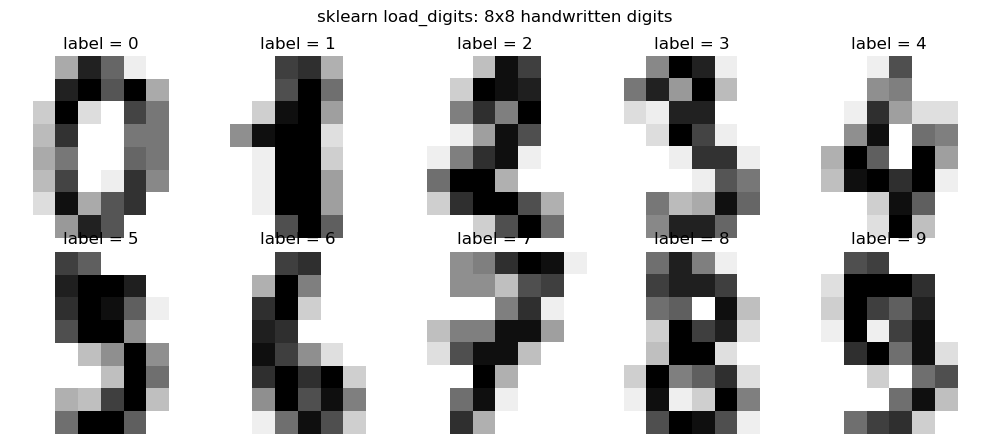


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): -0.0000 / 0.9682
표준화 후 test  평균/표준편차 (전체 픽셀 기준): 0.0012 / 1.0325   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [25]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.

3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)

A1.
분할 결과는 train: (1078, 64)  val: (359, 64)  test: (360, 64)로 배정되었음을 확인할 수 있다. 클래스별 샘플 수는 [178 182 177 183 181 182 181 179 174 180]로 거의 180 언저리인 것을 확인할 수 있기에 1주차 데이터와 달리 거의 불균형하지 않음을 확인할 수 있다. 이에 하나로만 예측을 진행한다면 정확도는 1/10, 즉 10%가 될 것이다.

A2. 
train data의 평균을 사용했기에 0이 아닐 것이다. `scaler.fit_transform(X_test)`를 사용한다면 우리가 알지 못한다고 가정한 test data의 정보까지 사용을 하게 되는 것이므로 데이터 누수가 발생하게 된다.

A3.
Validation data를 활용해 early stopping로 validation loss를 확인하여 학습을 멈출 시점을 정하고, test data는 최종 성능을 평가하기 위해 필요하다.

---

### 1.2 PyTorch로 MLP 학습하기 — 미니배치 SGD 루프를 직접 채우기

§1.1에서 준비한 데이터를 이용해 이제 **PyTorch MLP를 직접 학습**합니다. 모델과 손실 함수는 PyTorch가 제공하지만, 강의 p.47의 **미니배치 SGD 4단계**는 직접 코드로 완성합니다.

> **Loop:**
> 1. **미니배치 샘플링** — 전체 학습 데이터에서 일부를 미니배치로 추출
> 2. **순전파 및 손실 계산** — 미니배치를 모델에 입력하여 예측값과 손실을 계산
> 3. **역전파** — 손실을 기준으로 각 파라미터의 기울기를 계산
> 4. **파라미터 업데이트** — 계산된 기울기의 반대 방향으로 파라미터를 업데이트

이 네 단계는 PyTorch 코드와 거의 그대로 대응됩니다.

| 강의 단계 | PyTorch 코드 |
|---|---|
| 1. 미니배치 샘플링 | `for xb, yb in loader:` (DataLoader가 대신 수행) |
| 2. 순전파 + 손실 | `loss = criterion(model(xb), yb)` |
| 3. 역전파 | `loss.backward()` |
| 4. 업데이트 | `optimizer.step()` |
| (+) 기울기 초기화 | `optimizer.zero_grad()` ← **매 스텝 맨 앞에!** |

⚠️ **`optimizer.zero_grad()`를 빠뜨리면** PyTorch는 gradient를 덮어쓰지 않고 **누적**합니다. 이전 미니배치의 기울기가 계속 더해져 학습이 의도와 다르게 진행되므로, 순서(`zero_grad → forward/loss → backward → step`)를 기억하세요.

**`nn.CrossEntropyLoss`의 주의점** — 이 함수는 내부에서 softmax와 cross entropy 계산을 함께 처리합니다. 따라서 모델의 마지막 층은 **`nn.Linear`로 끝내고 softmax를 따로 붙이지 않습니다.** softmax를 추가하면 같은 변환이 중복되어 학습 성능이 나빠질 수 있습니다.

**`model.train()` / `model.eval()`** — Dropout(§1.4)처럼 학습할 때와 평가할 때 **동작이 달라지는 층**이 있으므로 모드를 명시해야 합니다. `torch.no_grad()`는 평가 중 gradient 계산 그래프를 만들지 않아 메모리 사용량과 계산량을 줄입니다.

**이번 절의 모델 (강의 p.28 표대로):** `Input 64` → `Hidden 64 (ReLU)` → `Hidden 32 (ReLU)` → `Output 10`


In [26]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x313c52f20>
  <function evaluate at 0x30d843240>
  <function train_model at 0x30d8434c0>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


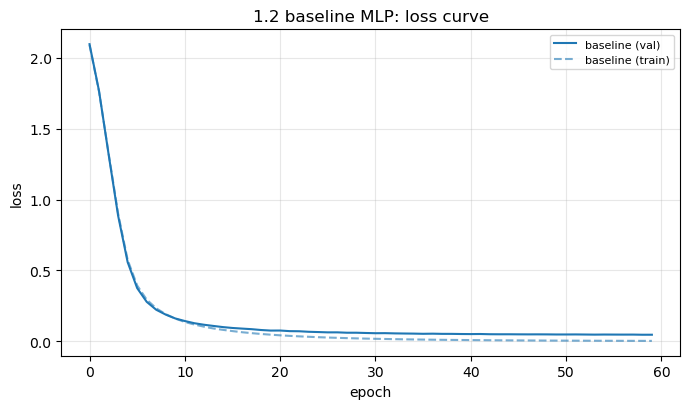

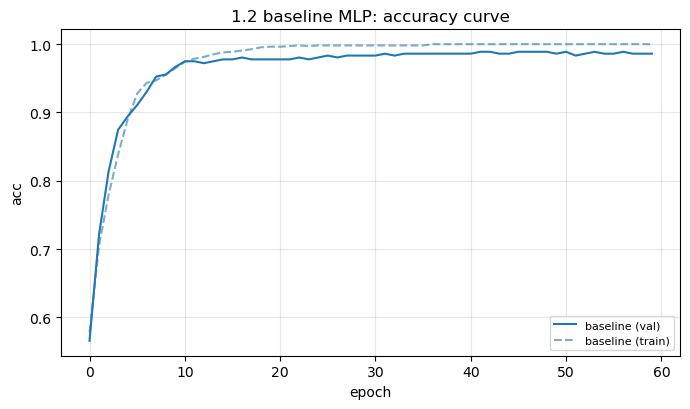


[최종] test loss = 0.0923 | test accuracy = 0.9806
val_loss 최저 epoch = 59 (val_loss = 0.0469)
마지막 epoch 의 train_loss = 0.0035 / val_loss = 0.0470
train_acc = 1.0000 / val_acc = 0.9861


In [27]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base['val_loss'])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요?

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요.

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.

5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)

A1.
4160+2080+330=6570이므로 출력된 파라미터 수: 6570와 일치한다.

A2.
test accuracy = 0.9806이므로 10%보다 아득히 높은 정확도를 보여준다.

A3.
val_loss 최저 epoch = 59 (val_loss = 0.0469), 마지막 epoch 의 train_loss = 0.0035 / val_loss = 0.0470로 epoch 59를 기준으로 0.0001만큼 올라갔음을 알 수 있다. 따라서 early stopping을 적용한다면 val loss가 가장 낮은 59 epoch의 모델을 선택하는 것이 적절할 것이다.

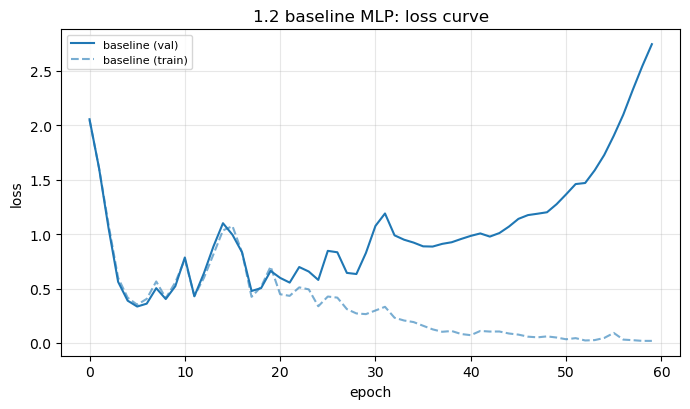

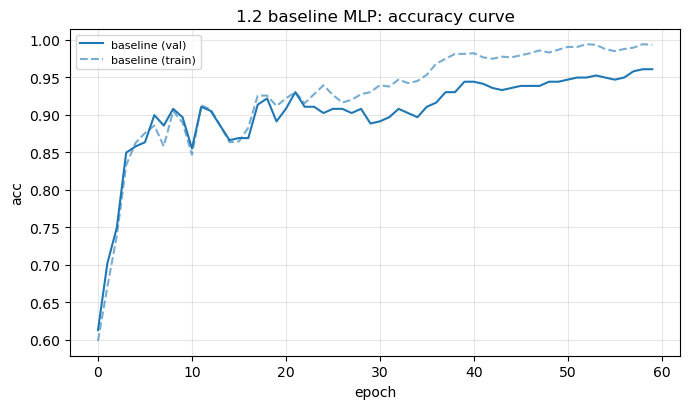


[최종] test loss = 6.8337 | test accuracy = 0.9306
val_loss 최저 epoch = 6 (val_loss = 0.3345)
마지막 epoch 의 train_loss = 0.0194 / val_loss = 2.7426
train_acc = 0.9935 / val_acc = 0.9610


In [28]:
# A4 모델
def train_model_2(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            # optimizer.zero_grad() #생략
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

baseline_2 = build_mlp(hidden=(64, 32), act=nn.ReLU)
hist_base_2 = train_model_2(baseline_2, epochs=60, opt_name="adam", lr=1e-3)

plot_curves({"baseline": hist_base_2}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base_2}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss_2, test_acc_2 = evaluate(baseline_2, Xte, yte)
print(f"\n[최종] test loss = {test_loss_2:.4f} | test accuracy = {test_acc_2:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep_2 = int(np.argmin(hist_base_2['val_loss'])) + 1
print(f"val_loss 최저 epoch = {best_ep_2} (val_loss = {min(hist_base_2['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base_2['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base_2['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base_2['train_acc'][-1]:.4f} / val_acc = {hist_base_2['val_acc'][-1]:.4f}")

A4. val loss가 epoch 6을 기점으로 올라가는 모습을 보인다. PyTorch에서 gradient는 누적되어 저장되기 때문에 이전에 계산된 gradient 값이 과도하게 큰 값이거나 작은 값이면 모델이 수렴하지 못하고 학습이 불안정해질 수 있다. 

Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
  (5): Softmax(dim=1)
)
파라미터 수: 6570


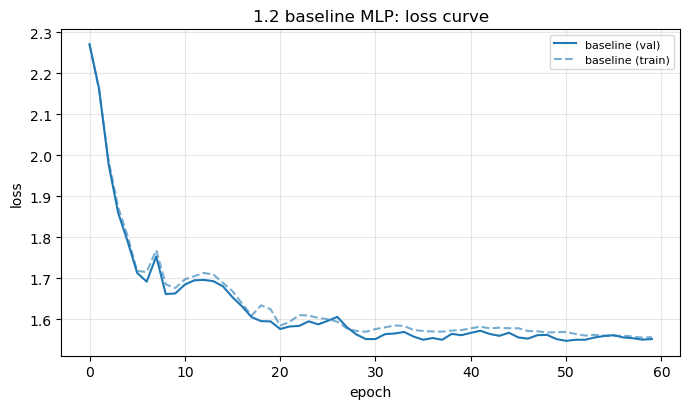

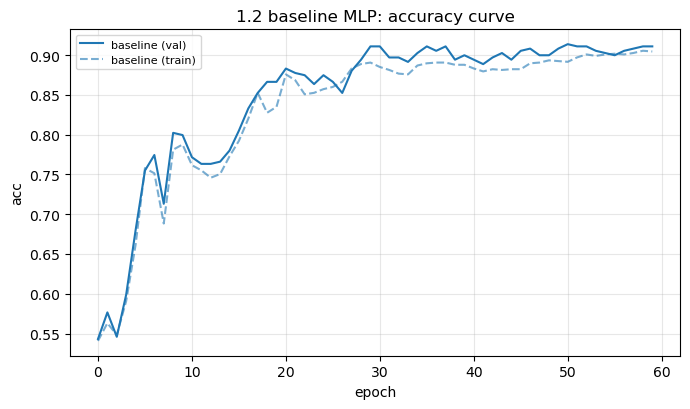


[최종] test loss = 1.6059 | test accuracy = 0.8556
val_loss 최저 epoch = 51 (val_loss = 1.5475)
마지막 epoch 의 train_loss = 1.5567 / val_loss = 1.5520
train_acc = 0.9045 / val_acc = 0.9109


In [29]:
#A5 (LLM 활용)
def build_mlp_2(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    layers.append(nn.Softmax(dim=1))
    return nn.Sequential(*layers)

baseline_3 = build_mlp_2(hidden=(64, 32), act=nn.ReLU)
print(baseline_3)
print("파라미터 수:", count_params(baseline_3))

hist_base_3 = train_model_2(baseline_3, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base_3}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base_3}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss_3, test_acc_3 = evaluate(baseline_3, Xte, yte)
print(f"\n[최종] test loss = {test_loss_3:.4f} | test accuracy = {test_acc_3:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep_3 = int(np.argmin(hist_base_3['val_loss'])) + 1
print(f"val_loss 최저 epoch = {best_ep_3} (val_loss = {min(hist_base_3['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base_3['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base_3['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base_3['train_acc'][-1]:.4f} / val_acc = {hist_base_3['val_acc'][-1]:.4f}")


A5. 연산 중복으로 인해 부정확한 결과가 나올 것으로 예상해볼 수 있으며, 실재로 test accuracy = 0.8556로 정확도가 많이 내려갔음을 확인할 수 있다. Softmax로 변환된 확률값에 다시 softmax를 적용하여 결과가 왜곡될 수 있기에 결과가 안좋아졌을 것이다.

---

### 1.3 Issue 1) Vanishing Gradient — 강의의 주장을 gradient로 직접 재기

강의 4장은 "Deep architecture는 input에서 output까지 gradient chain이 길어서 **Vanishing Gradient**가 생기고, 처방은 **non-saturating 활성화 함수(ReLU 계열)**"라고 말합니다(p.37~38). 여기서는 그 말을 **숫자로 확인**합니다.

**실험 설계**

- 은닉층 **8개**(width 32)를 쌓은 깊은 MLP를 두 개 만듭니다. **딱 하나만 다릅니다: 활성화 함수가 Sigmoid냐 ReLU냐.**
- 아직 **학습은 하지 않고**, 초기 파라미터에서 **역전파를 딱 한 번** 돌립니다.
- 그리고 **각 층 가중치의 gradient 크기(L2 norm)** 를 재서, 출력층에서 입력층으로 갈수록 얼마나 작아지는지 봅니다.
- 마지막으로 두 네트워크를 실제로 40 epoch 학습시켜 **성능 차이**를 확인합니다.

**왜 gradient의 norm인가?** gradient가 0에 가깝다는 것은 "이 층의 가중치를 아무리 바꿔도 loss가 거의 안 변한다 → **업데이트 신호가 없다 → 학습이 안 된다**"는 뜻입니다. Sigmoid를 한 번 지날 때마다 도함수 $h(1-h) \le 0.25$가 곱해지므로, 층이 깊어질수록 앞쪽 층의 gradient는 기하급수적으로 줄어듭니다.

> 📌 **이 절의 결과가 강의 마지막 서술형 퀴즈의 답입니다.** 그래프를 캡처해 기술블로그에 넣고, "chain rule 관점에서 왜 사라지는가"를 본인 숫자로 설명하세요.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  2.40e-07 2.54e-07 1.43e-06 1.12e-05 7.80e-05 6.20e-04 5.27e-03 3.88e-02 2.56e-01
[ReLU]     1.15e-03 7.02e-04 7.23e-04 8.84e-04 9.89e-04 1.89e-03 3.73e-03 5.32e-03 1.30e-02

Sigmoid: 마지막층 / 첫번째층 = 1.067e+06 배
ReLU   : 마지막층 / 첫번째층 = 1.136e+01 배


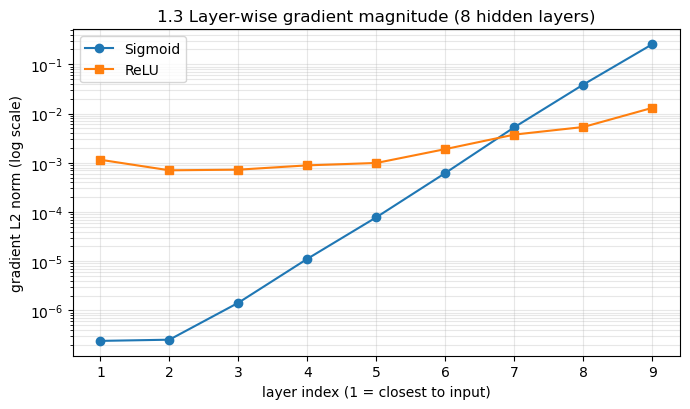

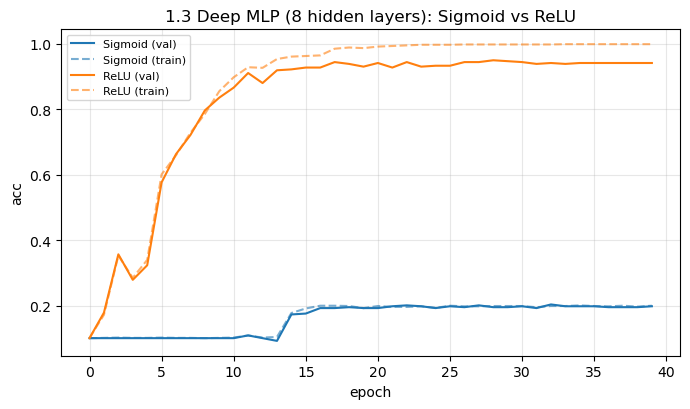


[Sigmoid 8층] 최종 train_acc = 0.1994 / val_acc = 0.1978
[ReLU    8층] 최종 train_acc = 0.9991 / val_acc = 0.9415
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9861


In [30]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.

A1. 
[Sigmoid]  2.40e-07, ..., 2.56e-01이므로 거의 $10^6$배만큼 차이가 난다는 것을 알 수 있다. 반면 [ReLU] 1.15e-03, ..., 1.30e-02이므로 10배정도의 차이가 났음을 확인할 수 있다. 이는 곧 sigmoid 네트워크에서 입력에 가까운 층의 gradient가 더 많이 사라졌음을 의미한다.

A2. 
첫 번째 층까지 도달하는 gradient에는 뒤에 있는 층들의 가중치와 sigmoid의 도함수들이 곱해지며 계산이 되기 때문에 0.25보다 작은 값들이 곱해지며 점점 작아지게 될 것이다. 반면 ReLU의 도함수는 양수 구간에서 아예 1이 되어버리기 때문에 거의 작아지지 않는다.

A3.
[Sigmoid 8층] 최종 train_acc = 0.1994, [ReLU 8층] 최종 train_acc = 0.9991로 sigmoid의 최종 train accuracy가 현저히 작음을 확인할 수 있을 것이다. 이는 강의에서 배웠던 vanishing gradient 문제로 앞쪽 층의 gradient가 거의 0에 가까워지면서 학습 자체가 되지 못하였음을 의미한다.

A4.
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9861, [ReLU 8층] 최종 val_acc = 0.9415로, 오히려 얇은 층의 validation accuracy가 더 높음을 알 수 있다. 이는 곧 너무 깊은 층으로 인해 overfitting이 일어났음을 예상해볼 수 있다. 

A5.
Sigmoid의 도함수가 $\sigma'(z) = h(1-h) \le 0.25$ 였으므로 chain rule에서 sigmoid의 도함수가 곱해짐에 따라 입력층의 graient가 거의 0에 가까워졌기에 거의 학습을 하지 못하였음을 알 수 있다. 이를 해결하기 위해 은닉층에서 ReLU, Leaky ReLU, ELU, GELU 등의 함수를 사용하거나 layer normalization로 안정화를 하는 방법을 사용할 수 있다.

---

### 1.4 Issue 2) Overfitting — 네 가지 처방을 같은 조건에서 붙여 보기

강의 p.39는 과적합을 "Training error는 줄지만 Generalization 성능은 낮음 / **노이즈까지 기억하는** 상태"로 정의하고, 처방 네 가지를 제시했습니다.

| Remedy | 아이디어 | 이번 실험에서 |
|---|---|---|
| ① **Early Stopping** | val loss가 개선되지 않으면 중단 | `val_loss` 최저 epoch를 찾아 "여기서 멈췄어야 했다"를 확인 |
| ② **Data Augmentation** | label을 유지하는 노이즈 데이터로 robustness 향상 | (심화 §2-C에서 도전 가능) |
| ③ **L1/L2 Regularization** | `Loss = error + 모델 크기` | `weight_decay` 로 L2 적용, 강도 2단계 비교 |
| ④ **Dropout** | 매 스텝 유닛을 확률적으로 비활성화 | `p_drop=0.5` (강의 권장값: hidden 50%) |

**과적합을 일부러 만듭니다.** §1.2의 모델은 데이터가 충분해 과적합이 약했습니다. 그래서 이번엔 **훈련 데이터를 150개로 줄이고**(전체의 약 14%) 모델을 **256-256으로 키워** 극단적인 상황을 만듭니다. 데이터는 적고 파라미터는 많으니 모델이 150개를 통째로 외워 버리기 좋은 조건입니다.

**공정 비교의 원칙:** 네 조건에서 **바뀌는 것은 규제 하나뿐**이고 데이터·구조·시드·epoch 수는 모두 동일합니다. 그래야 차이의 원인을 규제로 돌릴 수 있습니다.

⚠️ **Dropout 주의:** `model.train()`일 때만 뉴런을 끄고, `model.eval()`에서는 모두 켠 채 스케일을 보정합니다(강의 p.43: "추론 시 출력에 p를 곱해 기댓값을 맞춘다"). §1.2에서 `evaluate()` 안에 `model.eval()`을 넣은 이유가 바로 이것입니다 — 빠뜨리면 평가할 때마다 결과가 달라집니다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


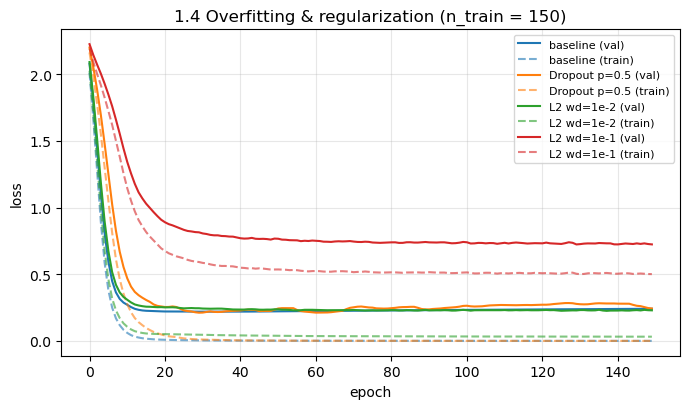

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0002    0.2408  0.2406     1.0000   0.9331       32       0.9359
Dropout p=0.5        0.0001    0.2430  0.2429     1.0000   0.9359       30       0.9499
L2 wd=1e-2           0.0316    0.2291  0.1975     1.0000   0.9359      138       0.9499
L2 wd=1e-1           0.5007    0.7236  0.2229     0.9333   0.8468      130       0.8496

[Early Stopping] baseline 은 epoch 32 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 118 epoch 를 낭비)


In [31]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr), size=150, replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden=(256, 256), p_drop=p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)

A1. 
train loss는 0.0002로 매우 작았던 반면 val loss는 0.2408로 차이가 0.2406만큼 났음을 알 수 있다. 마찬가지로 train acc는 아예 1이 나와버려 데이터를 완벽하게 학습했음을 알 수 있지만 val acc는 1이 나오지 않고 0.9331이 나와 차이가 좀 있음을 확인할 수 있다. 이는 곧 training data에 대해서는 error가 거의 없지만 validation data에 적용을 해봤을 때는 성능이 그만큼 나오지 않아 generalization 성능은 다소 떨어진다는 것을 확인할 수 있다.

A2. 
Epoch가 32였을 때 val loss가 0.2408로 최소였다. 이는 32/150, 즉 21.33% 지점이다. Early Stopping은 모델 구조나 파라미터를 추가하지 않고 val loss를 봐가며 이 수치가 가장 적은 모델을 선택하기만 하면 된다는 점에서 “공짜에 가까운 규제”라고 볼 수 있다.

A3. 
결과 : Dropout p=0.5 : 0.0001, 0.2430, 0.2429, 1.0000, 0.9359, 30, 0.9499 (train_loss,  val_loss, gap,  train_acc,  val_acc,  best_ep, best_val_acc)
최종 val loss는 baseline 모델보다 나빠졌으나 best val acc는 오히려 좋아졌음을 알 수 있다. 이는 accuracy는 단순히 맞힌 개수만을 세지만 loss는 에측의 확신도까지 고려를 하기 때문에 만약 낮은 확률로 정답을 맞히게 된다면 loss는 커지게 된다. 

A4.
해당 모델에서는 train loss와 val loss가 굉장히 커졌고 train acc이 0.93인 반면 val acc가 0.84에 그쳤음을 확인할 수 있다. 이는 loss가 과도하게 커졌고 val acc이 크게 감소했다는 점에서 오히려 과소적합이 일어났음을 알 수 있다. 따라서 L2 규제까지 하였음에도 과소적합이 일어났다는 점을 통해 오히려 과도한 규제는 좋지 못함을 확인할 수 있다.

A5.
L2 wd=1e-2가 loss 간 gap이 가장 작고 best val acc기 가장 높았다는 점에서 해당 모델이 가장 적잘하다고 볼 수 있다. 강의 내용에서의 Dropout은 일반적으로 0.5를 둔다고 했지만 해당 실습에서는 오히려 훈련 샘플이 너무 적인 상황에서 뉴런의 절반을 껐기 때문에 학습 가능한 정보가 과도하게 줄었다는 것을 확인할 수 있다. 이러한 경우 권장값보다 개인의 판단에 맞추어 모델을 만드는 것이 더 중요하다는 것을 깨달을 수 있다. 

---

### 1.5 Issue 3) Optimization — SGD / Momentum / Adam을 같은 출발선에서

강의 p.45~50은 optimizer의 계보를 보여 줬습니다.

$$\text{GD} \to \text{SGD(minibatch)} \to \text{Momentum},\ \text{RMSProp} \to \text{Adam}$$

- **Mini-batch SGD**: 전체가 아닌 일부로 gradient를 계산해 **자주** 업데이트
- **Momentum**: `업데이트 = 현재 gradient + 과거 gradient` — 방향이 자주 바뀌는 축은 상쇄, 일관된 축은 가속 → 지그재그 완화, 안장점 탈출
- **Adaptive (AdaGrad → RMSProp)**: gradient가 컸던 파라미터는 학습률을 줄이고 작았던 파라미터는 키움
- **Adam**: Momentum(**방향**) + RMSProp(**크기**) = "어디로 + 얼마나"

**실험 설계** — 모델·데이터·시드·epoch를 완전히 고정하고 **optimizer만** 바꿉니다. 학습률이 optimizer마다 적정 범위가 다르므로, SGD 계열은 `lr=0.05`, Adam은 관례적 기본값 `lr=0.001`을 씁니다. 여기에 **일부러 학습률을 크게 준 `SGD lr=3.0`** 도 넣어 무슨 일이 벌어지는지 봅니다.

비교 지표는 두 가지입니다: **① 최종 성능**(어디까지 갔나)과 **② 수렴 속도**(val accuracy 90%에 몇 epoch만에 도달했나).

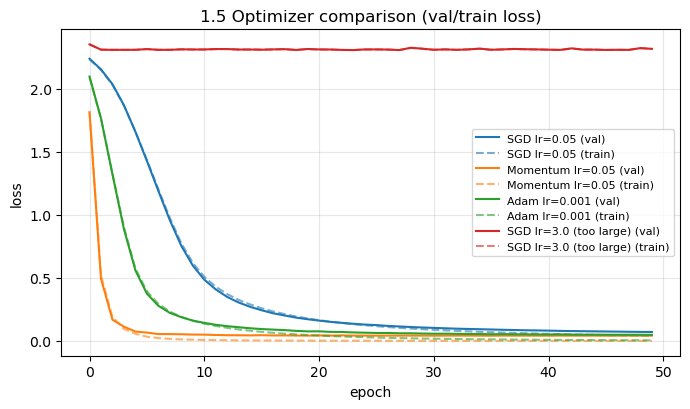

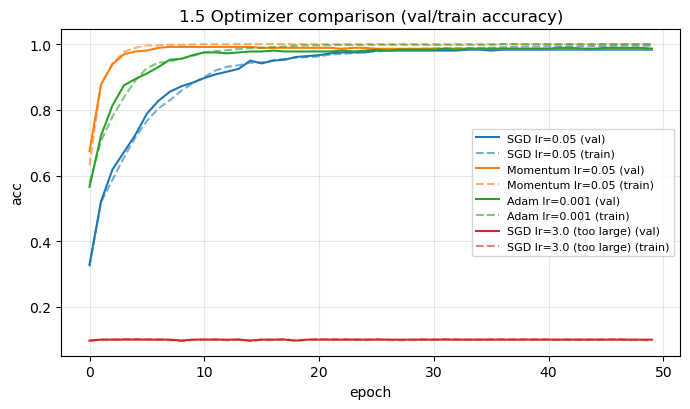

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.2372            0.0408         0.9833        0.9833               12
Momentum lr=0.05           1.8137            0.0008         0.9861        0.9916                3
Adam lr=0.001              2.0960            0.0055         0.9861        0.9889                6
SGD lr=3.0 (too large)       2.3505            2.3159         0.1003        0.1003             None


In [32]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64, 32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.

2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.

A1. 
SGD : 12, Momentum : 3, Adam : 6일 때 val acc이 90%에 도달하였다. Momentum은 SGD와 달리 과거 gradient을 누적하므로 계속 같은 방향으로 이동할 때는 움직임을 최소화해 더 빠른 최적화가 가능하다.

A2. 
최종 val acc는 각각 0.9833, 0.9861, 0.9861로 거의 차이가 없던 반면 수렴은 확연히 차이가 났음을 볼 수 있다. 따라서 수렴이 빠르다고 하여 최종 성능에 유의미한 영향을 주지는 못함을 알 수 있다. 

A3. 
SGD lr=3.0은 50 epoch 동안 val acc가 0.1003을 벗어나지 못하였음을 알 수 있다. 그러나 첫 epoch의 val loss는 2.3505로 다른 모델들과 큰 차이를 보이지는 않는데, 사실 10개 클래스에 모두 동일하게 0.1의 확률을 주는 모델의 cross entropy는 $-\ln(\frac{1}{10})=\ln(10)=2.3$  이므로 2.3이라는 수치는 사실상 무의미하다. 

A4.
① 미니배치 SGD는 full-batch GD보다 한 epoch당 파라미터 업데이트 횟수가 많지만, 각 업데이트의 gradient는 일부 데이터로 계산하므로 full-batch gradient보다 정확하지는 못하다
⑥ RMSProp의 decay rate $\rho$ 를 1에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되고, 0에 가까울수록 현재 gradient에 더 의존한다.

A5.
모든 파라미터에 똑같은 학습률을 적용하는 SGD와 달리 Adam은 RMSProp으로 얼마나 움직일지를 정하기 때문에 더 작은 학습률을 쓰면서 방향과 크기를 함께 조절하여 더 빨리 수렴할 수 있었을 것이다.

---

# 2. 심화 과제 — 스스로 생각하기

여기까지는 "돌리면 나오는" 영역이었습니다. 진짜 실력은 **그 값을 어떻게 읽고 판단하느냐**에서 갈립니다.
아래 세 문제는 모두 **강의 슬라이드가 주장한 것을 본인 실험으로 검증하거나 반증**하는 구조입니다. 슬라이드와 다른 결과가 나오면 **그대로 쓰고 원인을 추론**하세요.

---

### 2-A. 활성화 함수를 없애면? — "층을 쌓아도 선형"임을 직접 증명

강의 p.21은 이렇게 묻고 답했습니다.

> **Q. Why neural networks use Activation Functions?**
> **A. To introduce non-linearities into the network**

강의에서 수식으로 설명한 주장을 이제 **실험으로 확인**합니다. 활성화 함수 자리에 `nn.Identity()`(아무것도 안 하는 층)를 넣어 **은닉층이 2개인데도 사실은 선형 모델**인 네트워크를 만들고, 세 가지를 비교합니다.

| 모델 | 구조 | 파라미터 수 |
|---|---|---|
| **linear-deep** | 64 → 64 → 32 → 10, 활성화 **없음** | 6,570 |
| **single Linear** | 64 → 10, 은닉층 자체가 없음 | 650 |
| **ReLU MLP** (§1.2) | 64 → 64 → 32 → 10, ReLU | 6,570 |

그리고 **결정적 증거**로, linear-deep의 가중치 행렬 세 개를 곱해 **하나의 $10\times64$ 행렬로 접은 뒤**, 그 단일 선형변환이 원래 네트워크와 **똑같은 출력**을 내는지 확인합니다.

$$
W_{\text{eq}} = W^{(3)}W^{(2)}W^{(1)}, \qquad
b_{\text{eq}} = W^{(3)}\big(W^{(2)}b^{(1)} + b^{(2)}\big) + b^{(3)}
$$

In [33]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(m, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ Ws[1] @ Ws[0] 
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9583
single Linear(64->10)          650    0.9583
ReLU MLP (64,32)              6570    0.9806

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 1.526e-05   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 5.125e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = ____ / single Linear = ____ / ReLU MLP = ____

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.

A1.
둘다 선형 함수이며 nn.Identity를 썼다는 점에서 거의 차이가 없을 것으로 예상된다. 그래도 linear-deep이 아주 약간은 더 크지 않을까 예상이 된다.

A2.
linear-deep: 0.9583 / single Linear: 0.9583 / ReLU MLP: 0.9806

A3.
두 출력의 최대 차이 1.526e-05는 함수가 달라서가 아니라 float32의 반올림 오차이다. 이 접기 실험은 모든 test sample의 클래스별 출력값을 비교하므로 더 강한 증거가 된다. 뒷 문제는 설명을 잘 못하겠어서 모범 답안을 참고하고 공부를 더 해봐야할 것 같습니다.

A4.
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 5.125e+01를 통해 ReLU에서는 꽤 큰 차이가 났음을 볼 수 있다. 이는 ReLU 함수가 양수는 z로 그대로 내보내기 때문에 입력에 따라 값이 달라져 행렬곱으로 표현할 수 없다.

A5.
강의의 “To introduce non-linearities into the network”는 곧 비선형 변환을 넣어 직선으로는 표현할 수 없는 복잡한 경계를 학습할 수 있게 한다는 것을 의미한ㄷ. 따라서 활성화 함수가 없으면 층을 100개 쌓아도 하나의 선형층과 같다.


---

### 2-B. Go Wider or Deeper? — 파라미터 수를 맞춰 놓고 공정하게 붙이기

강의 p.36은 이렇게 결론지었습니다.

> 모델 용량을 단순히 폭으로 늘리는 것보다(Wide), 적절한 구조를 가진 깊은 네트워크(Deep)가
> **파라미터를 더 효율적으로 사용해 높은 성능**을 낼 수 있다.

이 주장을 **공정하게** 검증하려면 두 모델의 **파라미터 수를 비슷하게 맞춰야** 합니다. 파라미터가 많은 쪽이 이기면 그건 구조의 승리가 아니라 용량의 승리니까요.

**설계**
- **Wide**: `64 → H → 10` (은닉층 1개) → 파라미터 수 $= 75H + 10$
- **Deep**: `64 → h → h → h → h → 10` (은닉층 4개) → 파라미터 수 $= 3h^2 + 78h + 10$

$H = 256$ 이면 19,210개. 이와 **10% 이내**로 맞는 $h$를 직접 찾아 넣으세요.

> ⚠️ **결과가 강의 슬라이드와 다르게 나올 수 있습니다.** 그래도 그대로 보고하고 원인을 추론하세요. 시드 하나로 결론 내리지 말고 **여러 시드에서 반복**해 보는 것이 이 절의 진짜 과제입니다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-64x4-10 파라미터 수 = 17290
파라미터 수 차이 = 9.99%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9861 | best val_acc = 0.9889 | test_acc = 0.9833 | final train_loss = 0.0033
Deep (4 x 64)    final val_acc = 0.9805 | best val_acc = 0.9833 | test_acc = 0.9694 | final train_loss = 0.0004


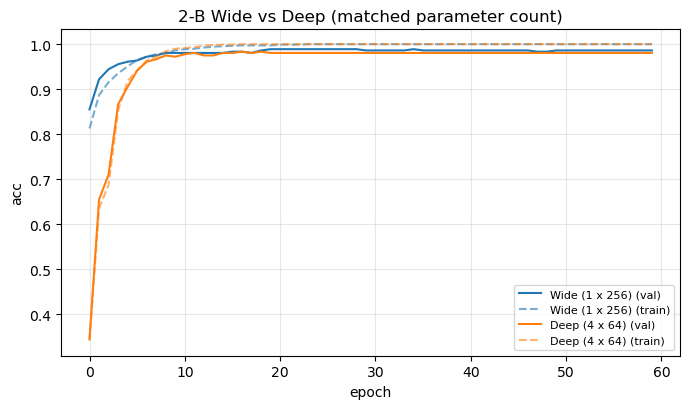


[여러 시드에서 반복]
  seed=0      wide=0.9833  deep=0.9694
  seed=1      wide=0.9833  deep=0.9722
  seed=42     wide=0.9806  deep=0.9694
  seed=4550   wide=0.9833  deep=0.9694
  seed=7777   wide=0.9806  deep=0.9667

Wide 평균 = 0.9822 (표준편차 0.0014)
Deep 평균 = 0.9694 (표준편차 0.0018)
Wide 가 이긴 횟수: 5 / 5


In [34]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = 64    #3h^2 + 78h + 10 = 17289가 되면 되므로 64를 넣었을때 17290이 되기에 h를 64로 설정하였다
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    wide_scores.append(evaluate(w, Xte, yte)[1])
    deep_scores.append(evaluate(d, Xte, yte)[1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**

**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?

**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.

A1. 
h는 64로 정하였으며 이때의 Deep의 파라미터 수는 17290이다. 이때의 Wide와는 1920만큼 차이가 나며 이것은 곧 9.99%만큼 차이가 난다. 파라미터 수를 비슷하게 맞춰야 파라미터의 수가 동등하다는 조건 하에 Wide와 Deep 차이를 구분할 수 있어 공정한 비교가 가능하다.

A2. 
Wide: 0.9833, Deep: 0.9694으로 해당 실험에서는 재현이 되지 못하였다.

A3. 
Wide 평균 = 0.9822 (표준편차 0.0014), Deep 평균 = 0.9694 (표준편차 0.0018)였으며 Wide가 5회 전부 이겼음을 확인할 수 있다. 시드 운이 아니군요.

A4.
- **(a)** 데이터가 너무까지는 아니여도 다소 적기는 하다. train: (1078, 64), val: (359, 64), test: (360, 64)였으며, 이때 Deep의 train loss는 0.0004로 매우 작았지만 정작 test acc는 0.9694로 Wide보다 못하였음을 통해 일반화를 하기에는 데이터의 양이 적었음을 의심해볼 수 있다. 
- **(b)** 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없을 수도 있다. 실제로 데이터 자체가 저화질이기 때문에 Wide 모델로도 충분히 학습을 진행했을 수도 있다. 
- (c) Deep이 아직 수렴하지 않았을 가능성은 낮다. Deep의 train loss가 오히려 Wide보다 더 낮다는 점에서 일반화 성능이 문제였다는 것을 알 수 있다. 
- (d) 4층 정도로는 "Deep"이라 하기 부족하다고 보기에는 위에서 언급하였듯 데이터 자체가 저화질이므로 4층이 충분했을 수도 있다. 
- **(e)** 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다고 볼 수 있다. Deep은 층이 여러개이므로 각 층에 대한 규제가 있어야 했을 수도 있었을 것이다. 

A5.
충분한 데이터가 있고, 데이터 자체의 구조가 복잡하고, 깊은 구조에 맞는 규제가 적용된 조건에서는 Deep 모델이 Wide 모델보다 높은 성능을 낼 수 있다. 그러나 적고 단순한 데이터에서는 깊이가 불필요할 수도 있고 오히려 일반화 성능을 낮출 수 있다. 강의에서 언급된 ResNet은 잔차 블록(Residual blocks)을 사용하여 Gradient Vanishing 문제를 완화하고 훨씬 Deep한 인공 신경망으로 훈련을 진행한다.

---

### 2-C. 나만의 최고 모델 만들기 (유형 C 맛보기)

지금까지의 실험에서 배운 것을 **하나의 모델에 종합**합니다.

**규칙**
1. **데이터 분할은 고정** — `Xtr / Xva / Xte`를 그대로 쓰세요. (새로 나누면 비교가 무의미해집니다.)
2. **test는 마지막에 딱 한 번만.** 모든 튜닝 결정은 **val**로 하세요. test를 보고 하이퍼파라미터를 고르면 그건 test가 아니라 두 번째 val입니다.
3. **방법은 자유** — 층 수·폭·활성화 함수·Dropout·L2·학습률·optimizer·batch size·epoch 수·Early Stopping 등 무엇이든.
4. **실험 기록 필수** — 시도한 조건과 val 성능을 아래 `log` 리스트에 **모두** 남기세요. 실패한 실험도 포함합니다.

**평가는 최종 정확도만 보지 않습니다.** *어떤 가설을 세워 무엇을 바꿨고, 결과가 그 가설을 지지했는지* 를 함께 봅니다.

> 💡 **출발점 힌트:** §1.2 baseline은 test 0.9667이었습니다. §1.4에서 L2가 효과적이었고, §1.5에서 Adam/Momentum이 빨랐으며, §2-B에서 이 데이터에는 Wide가 유리했습니다. 여기에 Early Stopping(val_loss 최저 시점의 가중치를 저장해 두었다가 복원)을 더하면 어떨까요?

In [35]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. 아래에 본인 실험을 최소 4개 이상 추가하세요. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
#   예) 가설: §1.4처럼 L2 가 도움이 된다면 wd 를 키울수록 val 이 좋아질 것이다
#       try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)
#   예) 가설: §2-B 에서 Wide 가 유리했으니 더 넓히면 더 좋아질 것이다
#       try_config("D. 더 넓게 (512,)", hidden=(512,))

# 가설 1: Wide 모델 + L2 wd=1e-2이 좋았기에 L2 wd=1e-2 활용
try_config("C. Wide + L2 wd=1e-2", hidden=(256,), wd=1e-2) #망함

# 가설 2: Wide가 더 좋았으니 폭을 넓혀볼 수 있다. 
try_config("D. Wide의 폭을 더 넓게 (512,)", hidden=(512,)) #성공

# 가설 3: Dropout p=0.3 적용 (훈련 데이터가 다소 적으니)
try_config("E. Dropout p=0.3 적용", hidden=(256,), p_drop=0.3) #망함

# 가설 4: Deep에 L2 규제를 추가하여 일반화 성능 향상 시도
try_config("F. Deep + L2 wd=1e-2", hidden=(64, 64, 64, 64), wd=1e-2) #망함

# 가설 5: Wide 모델 + L2 wd=1e-3정도를 적용
try_config("G. Wide + L2 wd=1e-3", hidden=(256,), wd=1e-3) #성공

# 가설 6: Deep 모델 + L2 wd=1e-3정도를 적용
try_config("H. Deep + L2 wd=1e-3", hidden=(64, 64, 64, 64), wd=1e-3) #망함

# 가설 7: Deep 모델을 좀 덜 deep 하게
try_config("I. Deep 2층", hidden=(128, 128)) #대성공

# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

A. baseline 재현 (64,32)                 best_val_acc=0.9889  (val_loss 최저 ep=80, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9889  (val_loss 최저 ep=80, params=19210)
C. Wide + L2 wd=1e-2                   best_val_acc=0.9889  (val_loss 최저 ep=59, params=19210)
D. Wide의 폭을 더 넓게 (512,)                best_val_acc=0.9916  (val_loss 최저 ep=80, params=38410)
E. Dropout p=0.3 적용                    best_val_acc=0.9889  (val_loss 최저 ep=63, params=19210)
F. Deep + L2 wd=1e-2                   best_val_acc=0.9777  (val_loss 최저 ep=37, params=17290)
G. Wide + L2 wd=1e-3                   best_val_acc=0.9916  (val_loss 최저 ep=64, params=19210)
H. Deep + L2 wd=1e-3                   best_val_acc=0.9833  (val_loss 최저 ep=73, params=17290)
I. Deep 2층                             best_val_acc=0.9944  (val_loss 최저 ep=46, params=26122)

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
I. Deep 2층 

In [36]:
# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
FINAL_HIDDEN   = (128, 128)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 0.0
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   = 80

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)


[최종 모델] val 최고 = 0.9944
[최종 모델] TEST accuracy = 0.9750  (baseline 대비 -0.0056)


**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.

**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: "____ 하면 ____ 할 것이다. 왜냐하면 §__ 에서 ____ 를 봤기 때문이다."
- 결과: val accuracy ____ → ____
- 판정 및 해석: ____

**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.

**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)

**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.

A1. 
======================================================================
실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
I. Deep 2층                                      0.9944       46   26122
D. Wide의 폭을 더 넓게 (512,)                         0.9916       80   38410
G. Wide + L2 wd=1e-3                            0.9916       64   19210
A. baseline 재현 (64,32)                          0.9889       80    6570
B. Wide + 약한 L2                                 0.9889       80   19210
C. Wide + L2 wd=1e-2                            0.9889       59   19210
E. Dropout p=0.3 적용                             0.9889       63   19210
H. Deep + L2 wd=1e-3                            0.9833       73   17290
F. Deep + L2 wd=1e-2                            0.9777       37   17290

A2. 
**Deep 2층 : 성공**
- 가설: “4층 Deep 모델을 2층으로 줄이고 각 층의 폭을 128로 넓히면 validation 성능이 향상될 것이다. 왜냐하면 §2-B에서 4층 Deep 모델은 일반화 성능이 별로 좋지 못하였기에 이 데이터에는 깊은 층수보다는 적절한 깊이와 폭이 더 중요할 수도 있기 때문이다."
- 결과: 0.9889 → 0.9944
- 판정 및 해석: Digits는 8×8의 단순한 이미지였으므로 4개의 층보다 2개의 적당히 넓은 층이 학습에 더 적합했던 것으로 판단된다.

**Deep 4층 + L2 wd=1e-2 : 실패**
- 가설: “4층 Deep 모델은 일반화 성능이 부족했는데 이는 곧 층에 규제가 없었다고 판단할 수 있다. 따라서 L2 규제를 주면 일반화 성능이 향상되어 val acc이 올라갈 수 있을 것이라 예상해볼 수 있다."
- 결과: 0.9889 → 0.9777
- 판정 및 해석: Digits는 8×8의 단순한 이미지였으므로 아무리 규제를 넣어도 너무 깊은 층은 성능 향상에 도움이 되지 못한다.


A3. 
val acc가 0.9944로 가장 높았던 최종 모델로 은닉층이 (128, 128)인 2층 ReLU MLP를 선택했다.

A4.
[최종 모델] val 최고 = 0.9944, TEST accuracy = 0.9750였으며, 이는 곧 val acc이 가장 높도록 반복적인 가설 설정을 하였기 때문에 validation에 대한 overfitting이 일어난 것일 수도 있다. 

A5.
Test 정보가 모델 선택 과정에 반영이 되므로 이 test data에만 잘 맞는 모델이 만들어졌을 수도 있다. 이는 결국 test data의 정보를 이용했다는 것, 즉 데이터 누수가 일어났음을 의미한다.

## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → 파라미터 수: 6570, test accuracy: 0.9806였다. Validation loss는 59 epoch에서 0.0469로 가장 낮았기에 59에서 early stopping을 적용해야 했다.
- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm $2.40\times10^{-7}$ vs 마지막 층 $2.56\times10^{-1}$. 이 차이가 train accuracy 0.1994로 이어진 인과를 한 문장으로: 최대 0.25인 sigmoid 도함수가 chain rule에 의해 입력 쪽의 gradient가 거의 사라졌다.
- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = 0.2406, Early Stopping 시점 = epoch 32. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: L2 wd=1e-2가 가장 좋았으며 val loss가 0.2291로 최소였고 best val acc이 0.9499로 최대였기 때문이다.
- **Optimization (§1.5):** val 90% 도달 epoch — SGD 12 / Momentum 3 / Adam 6. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: 수렴 속도에는 유의미한 차이가 있었으나 성능은 SGD 0.9833, Momentum 0.9861, Adam 0.9861로 거의 차이가 없었기에 속도와 성능은 별개의 문제임을 알 수 있다. 
- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 1.526e-05가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? Wide가 5회 모두 이겼으며 이는 강의 결과와 달랐고, 그 조건은 충분한 데이터가 있고, 데이터 자체의 구조가 복잡하고, 깊은 구조에 맞는 규제가 적용되었는가이다.
- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: 강의에서는 Deep 모델이 파라미터를 더 효율적으로 사용할 수 있다고 설명하지만, 해당 실습처럼 단순한 digits 데이터에서는 Wide가 더 우수한 성능을 보였으므로 딥러닝은 데이터의 복잡도와 조건에 따라 직접 검증해야 한다는 점을 배웠다.

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께: 1.4에서 loss와 accuracy로 모델 적합성을 평가하는 점이 어려웠습니다. L2 wd=1e-2의 train accuracy가 1.0000이었음에도 그 모델을 제일 좋다고 할 수밖에 없다는 점에 약간 의심이 들었으나 다른 모델들이 하나씩 큰 하자가 있어 해당 모델을 고르긴 하였고, 해당 실습을 통해 모델 선택의 과정이 다방면적으로 고려를 해야 한다는 것을 깨달을 수 있었습니다. 또한 2-A는 처음 접해보는 문제였기에 해결에 어려움을 겪었습니다.

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 1.2의 A5

- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

모델 마지막에 `nn.Softmax(dim=1)`을 어떻게 추가해?

실험용으로는 기존 `build_mlp()`를 변경하지 말고, 기존 모델 뒤에 Softmax를 붙이는 것이 가장 간단합니다.

```python
softmax_model = nn.Sequential(
    build_mlp(hidden=(64, 32), act=nn.ReLU),
    nn.Softmax(dim=1)
)

print(softmax_model)
```

구조는 다음과 같습니다.

```text
64 → 64 → ReLU → 32 → ReLU → 10 → Softmax
```

그다음 기존 함수로 동일하게 학습하면 됩니다.

```python
hist_softmax = train_model(
    softmax_model,
    epochs=60,
    opt_name="adam",
    lr=1e-3
)

softmax_test_loss, softmax_test_acc = evaluate(
    softmax_model,
    Xte,
    yte
)

print(
    f"Softmax 추가 모델: test loss = {softmax_test_loss:.4f}, "
    f"test accuracy = {softmax_test_acc:.4f}"
)
```

기존 baseline과 곡선을 비교하려면:

```python
plot_curves(
    {
        "normal": hist_base,
        "with Softmax": hist_softmax
    },
    "Normal logits vs Softmax output",
    metric="loss"
)

plot_curves(
    {
        "normal": hist_base,
        "with Softmax": hist_softmax
    },
    "Normal logits vs Softmax output",
    metric="acc"
)
```

함수 내부에 직접 추가하는 방식을 보고 싶다면 출력층 다음에 한 줄을 넣으면 됩니다.

```python
layers.append(nn.Linear(prev, out_dim))
layers.append(nn.Softmax(dim=1))
```

하지만 `build_mlp()`는 이후 과제에서도 사용하므로 원본 함수에 Softmax를 넣지 않는 것이 좋습니다. `dim=1`은 모델 출력의 shape이 `(배치 크기, 10)`일 때 두 번째 차원, 즉 10개 클래스 방향으로 확률의 합이 1이 되게 한다는 뜻입니다. 이번 실험에서는 이 확률을 `CrossEntropyLoss`에 입력하여 성능 변화를 확인합니다. 평소에는 `CrossEntropyLoss`에 Softmax 이전의 logits를 전달해야 합니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (여기에 답)
